# SPHEREx Self-calibration Dev

In [1]:
import glob
import os
import h5py
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400 # User can set this outside the class if needed

from astropy.io import fits
from astropy.io.votable import parse_single_table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u

import sys 
import gc 

import importlib
# sys.path.insert(0, '/home/thomasli/spherex/selfcal')
from SelfCal import EuclidUtility
from SelfCal import WCSHelper
from SelfCal import MakeMap
from SelfCal import MapHelper
importlib.reload(MapHelper)

import os
import h5py
from tqdm import tqdm
from multiprocessing import Pool 
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.table import Table

from reproject import reproject_interp
from reproject import reproject_exact
from reproject import reproject_adaptive

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr
import sys 
import gc 
from functools import partial

from SelfCal.MapHelper import bit_to_bool, make_weight, find_outliers, map_pixels,compute_chunk_contrib
from SelfCal.WCSHelper import load_from_fits, save_to_fits, find_optimal_frame
from SelfCal import PipelineWrapper


In [2]:
from SelfCal.SPHERExUtility import make_fiducial_chunk_mask, load_calibration, make_fiducial_chunk_map, extract_spherex_channel_edges, make_spherex_chunk_map, interp_2d_vertical

In [3]:
from SelfCal.MakeMap import *
from SelfCal.MapHelper import *

In [4]:
detector = 4

det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')

In [56]:
chunk_map, lvf_params = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=34, oversample_factor=2)
chunk_valid_mask = make_fiducial_chunk_mask([22],  num_subchannels=10, num_channels=34)
det_valid_mask = chunk_valid_mask[chunk_map]

Fitting LVF parameters...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:05<00:00, 59.30it/s]


Making chunk map...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:10<00:00, 34.03it/s]


### Test Coadd

In [47]:
importlib.reload(PipelineWrapper)
importlib.reload(MakeMap)
from SelfCal import PipelineWrapper

In [51]:
detector = 4
config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'nep_det{detector}_3p1arcsec'
config['resolution_arcsec'] = 3.1
cc = PipelineWrapper.Calibrator(config)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 4405/4405 [00:00<00:00, 1637354.58it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits


In [52]:
cc.reproj_list = cc.reproj_list
cc.exp_idx_list = cc.exp_idx_list
cc.det_idx_list = cc.det_idx_list

cc.setup_lsqr(
    apply_mask=True, 
    apply_weight=False, 
    chunk_map=chunk_map, 
    det_valid_mask=det_valid_mask, 
    max_workers=40, 
    outlier_thresh=10.0,
    ignore_list=[],
    oversample_factor=4,
    batch_size=10
    )

Processing 4405 items in 441 batches (Batch Size: 10)...


Building A, b matrix: 100%|███████████████████████████████████████████████████████████████████████████████████████| 441/441 [20:07<00:00,  2.74s/it]


LSQR setup completed in 1257.87 seconds.


In [7]:
detector = 4
config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'nep_det{detector}_3p1arcsec'
config['resolution_arcsec'] = 3.1


det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')

oversample_factor = 2
chunk_map, lvf_params = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=17, oversample_factor=oversample_factor)


Fitting LVF parameters...


  0%|                                                                                                                       | 0/171 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:03<00:00, 54.61it/s]


Making chunk map...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:05<00:00, 32.83it/s]


In [58]:
mm = PipelineWrapper.Mosaicker(config)
cal_path = '/mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/calibration/cal_34ch_det4_ch22.h5'
mm.load_calibration(cal_path=cal_path)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 4405/4405 [00:00<00:00, 616974.19it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/calibration/cal_34ch_det4_ch22.h5


In [9]:
ch = [10]
chunk_valid_mask = make_fiducial_chunk_mask(ch,  num_subchannels=10, num_channels=17)
det_valid_mask = chunk_valid_mask[chunk_map]

In [59]:
from SelfCal.SPHERExUtility import make_spherex_offset_map
from functools import partial
partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)

In [60]:
det_BC_up = upscale2d(det_BC, upscale_factor=2)
det_BW_up = upscale2d(det_BW, upscale_factor=2)
det_aux = np.stack([det_BC_up, det_BW_up], axis=0)

In [61]:
maps = mm.make_mosaic(
    apply_mask=True, 
    apply_weight=True, 
    chunk_map=chunk_map, 
    det_valid_mask=det_valid_mask, 
    max_workers=40,
    make_std_map=True, 
    apply_sigma_clipping=True,  
    sigma=1.0,
    ignore_list=[21],
    oversample_factor=2,
    det_offset_func=partial_make_offset_map,
    cache_batch_size=20,
    coadd_batch_size=100,
    cache_dir='/home/thomasli/spherex/selfcal/cache',
    cache_intermediate=True,
    det_aux=None
)


Caching intermediate computations...
Processing 4405 files in 221 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [28:42<00:00,  7.79s/it]


Cache computation finished in 1729.47 seconds.
Computing mean map...
Processing 4405 files in 45 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [05:54<00:00,  7.87s/it]


Mean map computation finished in 363.32 seconds.
Computing std map...
Processing 4405 files in 45 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [06:08<00:00,  8.19s/it]


Std map computation finished in 384.60 seconds.
Computing sigma-clipped mean map...
Processing 4405 files in 45 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [07:15<00:00,  9.68s/it]


Sigma-clipped mean map computation finished in 450.99 seconds.


In [74]:
cache_list = sorted(glob.glob('/home/thomasli/spherex/selfcal/cache/*.h5'))

In [86]:

mode = 'mean'
batch_files = cache_list[0:100]
batch_indices = np.arange(len(batch_files))
ref_shape = mm.ref_shape

# Execution Flags
use_cached = True

# Iterables
exp_idx_list = None
det_idx_list = None
offset_list = None


data_sum = np.zeros(ref_shape, dtype=np.float32)
weight_sum = np.zeros(ref_shape, dtype=np.float32)

# 4. Processing Loop
for i, file_path in enumerate(tqdm(batch_files)):
    idx = batch_indices[i]
    
    ref_coords, sub_data, sub_weight = None, None, None

    # --- A. GET DATA ---
    if use_cached:
        # Load from existing cache
        try:
            with h5py.File(file_path, 'r') as hf:
                ref_coords = hf['ref_coords'][:]
                sub_data = hf['sub_data'][:]
                sub_weight = hf['sub_weight'][:]
        except Exception as e:
            print(f"Error loading cached file {file_path}: {e}")
            continue
    else:
        continue

    # --- B. PROCESS DATA ---

    sub_crop, ref_crop = compute_crop(ref_shape, ref_coords)
    data_crop = sub_data[sub_crop]
    weight_crop = sub_weight[sub_crop]
    valid = ~check_invalid(data_crop)

    if mode == 'mean':
        data_sum[ref_crop] += np.where(valid, data_crop * weight_crop, 0.0)
        weight_sum[ref_crop] += np.where(valid, weight_crop, 0.0)

 12%|█████████████▏                                                                                                | 12/100 [00:10<01:17,  1.14it/s]


KeyboardInterrupt: 

In [112]:
idx = batch_indices[i]

ref_coords, sub_data, sub_weight = None, None, None

# --- A. GET DATA ---
if use_cached:
    # Load from existing cache
    try:
        with h5py.File(file_path, 'r') as hf:
            ref_coords = hf['ref_coords'][:]
            sub_data = hf['sub_data'][:]
            sub_weight = hf['sub_weight'][:]
    except Exception as e:
        print(f"Error loading cached file {file_path}: {e}")
else:
    pass

# --- B. PROCESS DATA ---

sub_crop, ref_crop = compute_crop(ref_shape, ref_coords)
data_crop = sub_data[sub_crop]
weight_crop = sub_weight[sub_crop]
valid = ~check_invalid(data_crop)

if mode == 'mean':
    data_sum[ref_crop] += np.where(valid, data_crop * weight_crop, 0.0)
    weight_sum[ref_crop] += np.where(valid, weight_crop, 0.0)

In [17]:
det_aux = np.array([grid_BC, grid_BW])

In [30]:
cache_list = compute_coadd_map('cache', mm.ref_shape, mm.file_list[0:100], mean_map=None, std_map=None, sigma=3.0, 
                      offset_list=offset[0:100], exp_idx_list=None, det_idx_list=None, apply_weight=False, 
                      apply_mask=True, chunk_map=chunk_map, det_valid_mask=det_valid_mask, 
                      max_workers=20, ignore_list=[21], det_offset_func=None, oversample_factor=2,
                      batch_size=10, valid_threshold=0.99,
                      cache_dir='cache/', det_aux=det_aux)

Processing 100 files in 10 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:32<00:00, 21.26s/it]


In [34]:
mean_map, mean_weight, aux_sum = compute_coadd_map('mean', mm.ref_shape, cache_list, mean_map=None, std_map=None, sigma=3.0, 
                      offset_list=offset[0:100], exp_idx_list=None, det_idx_list=None, apply_weight=False, 
                      apply_mask=True, chunk_map=chunk_map, det_valid_mask=det_valid_mask, 
                      max_workers=20, ignore_list=[21], det_offset_func=None, oversample_factor=2,
                      batch_size=10, valid_threshold=0.99,
                      cache_dir='cache/', use_cached=True, det_aux=det_aux)

Processing 100 files in 10 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [02:34<00:00, 15.48s/it]


In [83]:
# plt.imshow(maps['mean_map'], norm=LogNorm(), origin='lower')

In [ ]:
channel_edges = [0.87, 1.0]
chunk_map = make_spherex_chunk_map(detector, det_BC, fine_edges=channel_edges)
chunk_valid_mask = channel_edges==1

### Inspect Reproj FIle

In [ ]:
from SelfCal.MakeMap import _prep_subframe, load_reproj_file

In [ ]:
reproj_list = sorted(glob.glob('/data3/thomasli/selfcal/outputs/nep_det4_3p1arcsec/reprojected/*.h5'))
reproj_sample = load_reproj_file('/home/thomasli/spherex/selfcal/test_dir/exp_0000_det_00.h5', fields=['sub_data', 'sub_header', 'det_header', 
                                                         'ref_coords', 'file_path', 'sub_bitmask', 'sub_mapping', 'sub_foot'])

In [ ]:
# Get bytesizes of keys in the reproj file
total_bytes = 0
for key in reproj_sample.keys():
    if isinstance(reproj_sample[key], np.ndarray):
        print(f"{key}: {reproj_sample[key].nbytes / 1e6} MB")
        total_bytes += reproj_sample[key].nbytes

print(f"Total size: {total_bytes / 1e6} MB")

In [ ]:
# Get bytesizes of keys in the reproj file
total_bytes = 0
for key in reproj_sample.keys():
    if isinstance(reproj_sample[key], np.ndarray):
        print(f"{key}: {reproj_sample[key].nbytes / 1e6} MB")
        total_bytes += reproj_sample[key].nbytes
print(f"Total size: {total_bytes / 1e6} MB")

### _prep_subframe

In [123]:
importlib.reload(MakeMap)
importlib.reload(MapHelper)
from SelfCal.MakeMap import _prep_subframe
from SelfCal.MapHelper import *
import scipy.ndimage as nd


In [124]:
from SelfCal.SPHERExUtility import make_spherex_offset_map
partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)

In [53]:
importlib.reload(MakeMap)
from SelfCal import MapHelper
importlib.reload(MapHelper)
from SelfCal.MakeMap import _prep_subframe


In [ ]:
file = '/mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/reprojected/exp_1627_det_00.h5'
chunk_map = chunk_map
apply_weight=False
apply_mask=True
chunk_offset=None
det_offset_func=None
ignore_list=[]
det_valid_mask=det_valid_mask
valid_threshold=0.99
for_lsqr=True
oversample_factor=4
exp_idx=1627
det_idx=0

In [54]:
_prep_subframe(
    file=file, 
    chunk_map=chunk_map, 
    apply_weight=apply_weight, 
    apply_mask=apply_mask, 
    chunk_offset=chunk_offset, 
    det_offset_func=det_offset_func, 
    ignore_list=ignore_list, 
    valid_threshold=valid_threshold, 
    for_lsqr=for_lsqr, 
    oversample_factor=oversample_factor, 
    exp_idx=exp_idx, 
    det_idx=det_idx
)

(array([ 4916, 11221,  4948, 11253], dtype=int32),
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(6305, 6305), dtype=float32),
 array([[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]], shape=(6305, 6305), dtype=float32),
 <Compressed Sparse Column sparse matrix of dtype 'float32'
 	with 4291040 stored elements and shape (172, 39753025)>,
 None)

In [27]:
if ignore_list is None: ignore_list = []

fields = ['sub_data', 'ref_coords', 'sub_mapping']
if apply_mask:
    fields.append('sub_bitmask')
result = load_reproj_file(file, fields=fields)

In [28]:
sub_data = result['sub_data']
ref_coords = result['ref_coords']
sub_fullmask = np.ones_like(sub_data, dtype=bool)
sub_mapping = result['sub_mapping']

if 'sub_bitmask' in result:
    # invert=True: 1 = Good pixel, 0 = Bad pixel
    sub_boolmask = bit_to_bool(result['sub_bitmask'], ignore_list, invert=True)
    sub_fullmask &= sub_boolmask

In [29]:
interp_matrix = None
if (chunk_map is not None) or (chunk_offset is not None) or for_lsqr:
    sub_mapping_flat = sub_mapping.reshape(2, np.prod(sub_mapping.shape[1:]))
    sub_mapping_flat_scaled = sub_mapping_flat * oversample_factor
    interp_matrix = make_linear_interp_matrix(sub_mapping_flat_scaled[::-1], input_shape=np.shape(chunk_map))

In [19]:
if chunk_offset is not None:
    if det_offset_func is not None:
        det_offset = det_offset_func(chunk_map, chunk_offset)
    else:
        det_offset = chunk_to_det(chunk_map, chunk_data=chunk_offset)
    sub_offset = det_to_sub(det_offset, interp_matrix=interp_matrix)
    sub_data -= sub_offset

if det_valid_mask is not None:
    sub_valid_frac = det_to_sub(det_valid_mask, interp_matrix=interp_matrix)
    sub_valid_mask = sub_valid_frac > valid_threshold
    sub_fullmask &= sub_valid_mask


sub_data[~sub_fullmask] = np.nan

sub_weight = make_weight(sub_data) if apply_weight else np.ones_like(sub_data, dtype=np.float32)

In [20]:
chunk_contrib = None
if for_lsqr:
    # Note: If compute_chunk_contrib needs exp_idx/det_idx, ensure they are passed here.
    chunk_contrib = compute_chunk_contrib(chunk_map, interp_matrix)

In [229]:
# plt.plot(np.nanmean(offset_guess, axis=0))

In [34]:
def make_linear_interp_matrix_fast(coords, input_shape):
    """
    Optimized generation of sparse interpolation matrix.
    """
    # Coords = (y_coords, x_coords)
    H, W = input_shape
    N_total = coords.shape[1] 

    # 1. Identify valid inputs (removing NaNs)
    # np.isfinite is generally slightly faster than ~np.isnan
    valid_mask = np.isfinite(coords[0]) & np.isfinite(coords[1])
    valid_idxs = np.where(valid_mask)[0] # Indices in original array
    
    # Filter coordinates immediately
    row_coords = coords[0][valid_mask]
    col_coords = coords[1][valid_mask]
    
    n_valid = len(row_coords)
    if n_valid == 0:
        return coo_matrix((0, 0), shape=(N_total, H * W)).tocsr()

    # 2. Integer floors and fractional parts
    # Floor returns float, safe to cast to int32 for indexing
    r0 = np.floor(row_coords).astype(np.int32)
    c0 = np.floor(col_coords).astype(np.int32)
    
    r_frac = row_coords - r0
    c_frac = col_coords - c0
    rf_inv = 1.0 - r_frac
    cf_inv = 1.0 - c_frac

    # 3. Optimized Bounds Check (The bottleneck fix)
    # Instead of creating 'all_r' (size 4N), check bounds on 'r0' (size N)
    # Pre-calculate boolean masks for rows/cols being inside image
    in_r0 = (r0 >= 0) & (r0 < H)
    in_c0 = (c0 >= 0) & (c0 < W)
    in_r1 = (r0 + 1 >= 0) & (r0 + 1 < H)
    in_c1 = (c0 + 1 >= 0) & (c0 + 1 < W)

    # 4. Allocation
    total_entries = n_valid * 4
    
    # Use float32 for weights to save memory (sufficient precision for interp)
    data = np.empty(total_entries, dtype=np.float32)
    cols = np.empty(total_entries, dtype=np.int32)
    
    # Create the row indices repeated 4 times
    rows = np.repeat(valid_idxs, 4).astype(np.int32)

    # 5. Fill Weights and Indices (Strided assignment)
    base_idx = r0 * W + c0
    
    # We construct the bounds_mask directly using the pre-calced booleans
    bounds_mask = np.empty(total_entries, dtype=bool)

    # Top-Left (r0, c0)
    data[0::4] = rf_inv * cf_inv
    cols[0::4] = base_idx
    bounds_mask[0::4] = in_r0 & in_c0

    # Top-Right (r0, c0+1)
    data[1::4] = rf_inv * c_frac
    cols[1::4] = base_idx + 1
    bounds_mask[1::4] = in_r0 & in_c1

    # Bottom-Left (r0+1, c0)
    data[2::4] = r_frac * cf_inv
    cols[2::4] = base_idx + W
    bounds_mask[2::4] = in_r1 & in_c0

    # Bottom-Right (r0+1, c0+1)
    data[3::4] = r_frac * c_frac
    cols[3::4] = base_idx + W + 1
    bounds_mask[3::4] = in_r1 & in_c1

    # 6. Final Construction
    # Filter using the boolean mask
    keep_rows = rows[bounds_mask]
    keep_cols = cols[bounds_mask]
    keep_data = data[bounds_mask]

    interp_matrix = coo_matrix(
        (keep_data, (keep_rows, keep_cols)), 
        shape=(N_total, H * W),
        dtype=np.float32
    )
    
    return interp_matrix.tocsr()

In [35]:
from SelfCal.MapHelper import make_linear_interp_matrix

### Chunk Map

In [ ]:
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, load_calibration, interpolate_array, make_arc_spline

In [ ]:
detector = 1
det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
chunk_map, lvf_params = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=17, oversample_factor=2)

In [ ]:
plt.imshow(chunk_map)
for i in range(len(lvf_params['R'])):
    spl = make_arc_spline(lvf_params['xc'], lvf_params['yc'], lvf_params['R'][i])
    x_arc = np.linspace(0, 2040, 1000)
    y_arc = spl(x_arc)
    plt.plot(x_arc, y_arc, 'r-', linewidth=0.5, alpha=0.5)
plt.xlim(1450, 1950)
plt.ylim(0, 500)

In [ ]:
# plt.plot(fit_params['edge_index'], fit_params['xc'], '.')

### Examine Interpolation Methods

In [ ]:
from SelfCal.SPHERExUtility import interp_1d, parse_bin

In [ ]:
# x = np.arange(1000)
# org = np.exp(-(x-510)**2/100) + np.exp(-(x-530)**2/100) + (x/1000)**2 + \
#     np.exp(-(x-400)**2/100) + np.exp(-(x-410)**2/100) + np.exp(-(x-440)**2/100) + \
#      + np.exp(-(x-580)**2/10) + np.exp(-(x-630)**2/30) + np.exp(-(x-680)**2/60)
# binned = np.zeros_like(org)
# bin_size = int(2040/17/20)
# for i in range(0, len(org), bin_size):
#     binned[i:i+bin_size] = np.mean(org[i:i+bin_size])
# mpi = interp_1d(binned)
# lin = interp_1d(binned, method='linear')

# mean_idx, mean_val, _ = parse_bin(binned)
# # use pchip
# from scipy.interpolate import PchipInterpolator
# pchip_interp = PchipInterpolator(mean_idx, mean_val)
# scipy = pchip_interp(x)

# mean_idx, mean_val, edge = parse_bin(binned)
# mps_custom = mean_preserving_spline(edge, mean_val, method='cubic')
# mps_interp = mps_custom(x)

# plt.plot(x, org, label='Source', linewidth=1)
# # plt.plot(mean_idx, mean_val, 'o', label='Sampled Points', markersize=2, color='red')
# plt.step(x, binned, label='Binned', where='mid', linewidth=0.5, color='tab:red', alpha=0.7)
# # plt.plot(x, binned, label='Binned', linewidth=0.5)
# plt.plot(x, mpi, label='MPI Interpolated', ls='--', linewidth=0.5, color='tab:orange')
# plt.plot(x, lin, label='Linear Interpolated', ls='--', linewidth=0.5, color='tab:green')
# # plt.plot(x, mps_interp, label='Custom', linewidth=0.5, ls=':')


# # smaller legend
# plt.legend(fontsize='small')
# plt.xlim(350, 750)

In [ ]:
hdul = fits.open(exp_file)

In [ ]:
hdul.info()

### Full Test

In [5]:
detector = 4
file_suffix = ''
file_prefix = f'_34channels'

config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'nep_det{detector}_3p1arcsec'
config['resolution_arcsec'] = 3.1


det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')

oversample_factor = 2
num_subchannels = 10
num_channels = 34
chunk_map, lvf_params = make_fiducial_chunk_map(detector, det_BC, num_subchannels=num_subchannels, num_channels=num_channels, oversample_factor=oversample_factor)
det_chunk_map, _ = make_fiducial_chunk_map(detector, det_BC, num_subchannels=num_subchannels, num_channels=num_channels, 
                                           oversample_factor=1, lvf_params=lvf_params)



Fitting LVF parameters...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:05<00:00, 57.95it/s]


Making chunk map...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:10<00:00, 32.06it/s]


Making chunk map...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:02<00:00, 131.94it/s]


In [6]:
from SelfCal.SPHERExUtility import make_spherex_offset_map, compute_offsets_guess
from functools import partial
from SelfCal.SPHERExAppendWav import wav_coadd

In [ ]:
ch = [19]

print(f"Processing channel {ch} for detector {detector}")
chunk_valid_mask = make_fiducial_chunk_mask(ch,  num_subchannels=num_subchannels, num_channels=num_channels)
det_valid_mask = chunk_valid_mask[chunk_map]
cc = PipelineWrapper.Calibrator(config)
cc.setup_lsqr(
    apply_mask=True, 
    apply_weight=True, 
    chunk_map=chunk_map, 
    det_valid_mask=det_valid_mask, 
    max_workers=40, 
    outlier_thresh=10.0,
    ignore_list=[],
    oversample_factor=oversample_factor,
    batch_size=20
    )

Processing channel [19] for detector 4


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 4405/4405 [00:00<00:00, 1688685.60it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits


Processing 4405 items in 221 batches (Batch Size: 20)...


Building A, b matrix:  20%|█████████████████▌                                                                    | 45/221 [42:52<2:47:41, 57.17s/it]


In [6]:
import jax
import jax.numpy as jnp
from jax.experimental import sparse
import scipy.sparse as sp
from jaxopt.linear_solve import solve_normal_cg

In [7]:
A_jax = sparse.BCOO.from_scipy_sparse(cc.A)
b_jax = jnp.array(cc.b)

In [77]:
M, N = A_jax.shape

# 1. Create a dummy initialization vector of size N
# This tells JAX the shape of the solution it should produce
x_init = jnp.zeros(N)

def matvec(x):
    return A_jax @ x

# 2. Pass 'init=x_init' to the solver
x_sol = solve_normal_cg(
    matvec, 
    b_jax, 
    init=x_init,  # <--- CRITICAL ADDITION
    tol=1e-6, 
    maxiter=200
)
print("Solution shape:", x_sol.shape)

Solution shape: (319442782,)


In [ ]:
x_numpy = np.array(x_sol)

In [ ]:
num_sky = np.prod(cc.ref_shape)
num_exp = len(cc.exp_idx_list)
S = x_numpy[:num_sky].reshape(cc.ref_shape)
O = x_numpy[num_sky:].reshape(num_exp, (x_numpy.shape[0]-num_sky) // num_exp)

: 

In [63]:
with h5py.File('/mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/calibration/cal_34channels_D4_Ch19.h5', 'r') as hf:
    O_ref = hf['O'][:]

In [71]:
nonzero_index = O.nonzero()

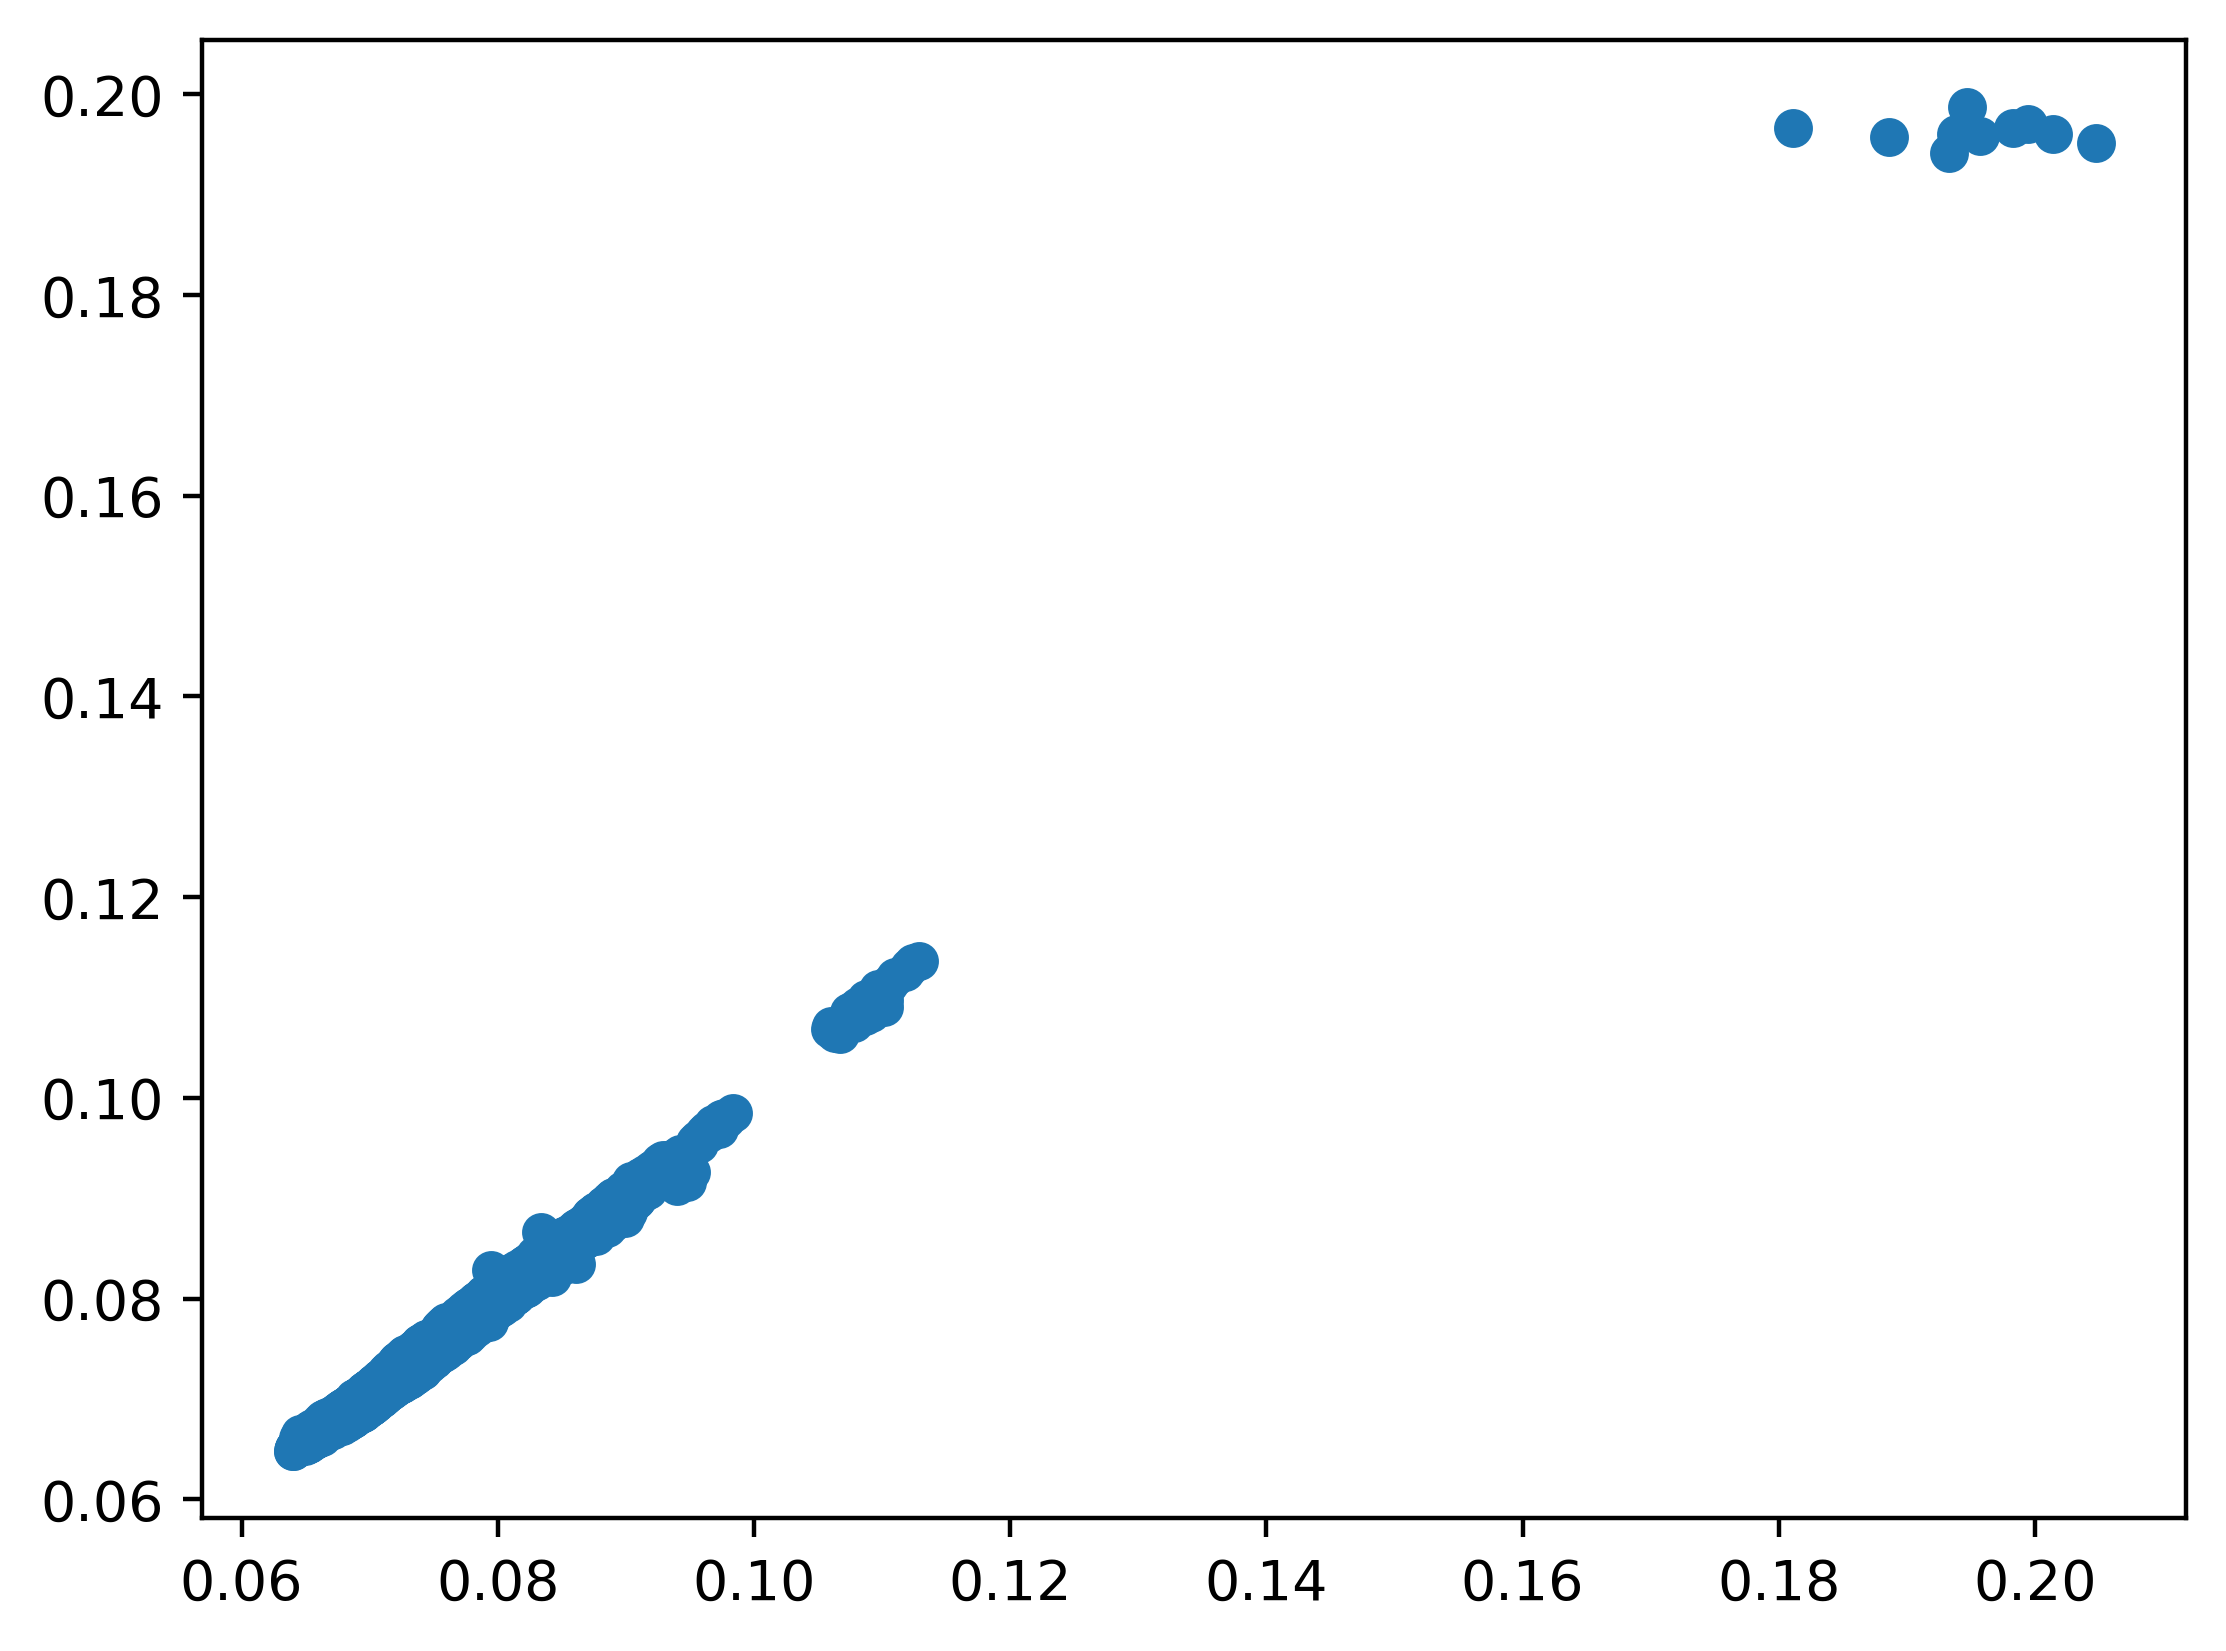

In [76]:
plt.scatter(O[:,chunk_valid_mask.astype(bool)], O_ref[:,chunk_valid_mask.astype(bool)])

In [ ]:
offset_guess = compute_offsets_guess(cc.reproj_list, det_chunk_map)
x0 = np.hstack([np.zeros(np.prod(cc.ref_shape)), offset_guess.flatten()])
cc.apply_lsqr(x0=x0, atol=1e-06, btol=1e-06, damp=1e-3, iter_lim=100)
cal_path = cc.save_calibration(cal_file=f'cal{file_prefix}_D{detector}_Ch{"-".join(map(str, ch))}{file_suffix}.h5')

del cc
gc.collect()

In [52]:
offset_guess = compute_offsets_guess(cc.reproj_list, det_chunk_map)


/home/thomasli/anaconda3/envs/general/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Calculating initial guess offsets:  37%|██████████████████████████▌                                             | 1622/4405 [00:40<00:52, 53.21it/s]/home/thomasli/anaconda3/envs/general/lib/python3.13/site-packages/scipy/ndimage/_measurements.py:810: RuntimeWarning: invalid value encountered in divide
  return sum / np.asanyarray(count).astype(np.float64)


Calculating initial guess offsets: 100%|████████████████████████████████████████████████████████████████████████| 4405/4405 [01:43<00:00, 42.67it/s]/home/thomasli/anaconda3/envs/general/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()



In [51]:
chunk_valid_mask * offset_guess

NameError: name 'offset_guess' is not defined

In [93]:
importlib.reload(PipelineWrapper)
from SelfCal.PipelineWrapper import Mosaicker

In [94]:
mm = PipelineWrapper.Mosaicker(config)
mm.load_calibration(cal_path=cal_path)
partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)
sigma = 1.0
maps = mm.make_mosaic(
    apply_mask=True, 
    apply_weight=True, 
    chunk_map=chunk_map, 
    det_valid_mask=det_valid_mask, 
    max_workers=40,
    make_std_map=True, 
    apply_sigma_clipping=True,  
    sigma=sigma,
    ignore_list=[21],
    oversample_factor=4,
    det_offset_func=partial_make_offset_map,
    cache_batch_size=20,
    coadd_batch_size=100,
    cache_dir='/home/thomasli/spherex/selfcal/cache',
    cache_intermediate=True,
    det_aux=None
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 4405/4405 [00:00<00:00, 1611786.54it/s]


Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/calibration/cal_34channels_D4_Ch19.h5
Caching intermediate computations...
Processing 4405 files in 221 batches...


  0%|                                                                                                                       | 0/221 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [37:33<00:00, 10.20s/it]


Cache computation finished in 2270.80 seconds.
Computing mean map...
Processing 4405 files in 45 batches...


...

Mean map computation finished in 422.21 seconds.
Computing std map...
Processing 4405 files in 45 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [06:59<00:00,  9.32s/it]


Std map computation finished in 440.24 seconds.
Computing sigma-clipped mean map...
Processing 4405 files in 45 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [07:11<00:00,  9.59s/it]


Sigma-clipped mean map computation finished in 456.66 seconds.


In [103]:
from SelfCal import SPHERExAppendWav
importlib.reload(SPHERExAppendWav)
from SelfCal.SPHERExAppendWav import wav_coadd

In [ ]:
reproj_list = mm.reproj_list
cache_list = mm.cached_list

mean_map = maps['mean_map']['data']
std_map = maps['std_map']['data']
ref_shape = mean_map.shape

wav_mean, wav_std = wav_coadd(det_BC, det_BW, mean_map, std_map, reproj_list, cache_list, ref_shape, sigma=sigma, 
                        batch_size=40, max_workers=40)    

wav_mean_maps = {'data': wav_mean, 'unit': 'um'}
wav_std_maps = {'data': wav_std, 'unit': 'um'}
mm.append_maps({'wav_mean_map': wav_mean_maps, 'wav_std_map': wav_std_maps})

mm.save_mosaic(mos_file=f'mosaic{file_prefix}_D{detector}_Ch{"-".join(map(str, ch))}{file_suffix}.fits', overwrite=True)

# Clear memory
del mm, maps
gc.collect()

Processing 4405 files in 111 batches with 40 workers...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 111/111 [24:17<00:00, 13.13s/it]


Cleaning up Shared Memory...
Mosaic saved to /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/mosaic/mosaic_34channels_D4_Ch19.fits


39404

In [98]:
mosaic_hdul = fits.open(f'/mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/mosaic/mosaic_34channels_D4_Ch19.fits')
mosaic_hdul.info()

Filename: /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/mosaic/mosaic_34channels_D4_Ch19.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  MEAN_MAP      1 ImageHDU        24   (18268, 17404)   float32   
  2  MEAN_MAP_WEIGHT    1 ImageHDU        24   (18268, 17404)   float32   
  3  STD_MAP       1 ImageHDU        24   (18268, 17404)   float32   
  4  STD_MAP_WEIGHT    1 ImageHDU        24   (18268, 17404)   float32   
  5  SC_MEAN_MAP    1 ImageHDU        24   (18268, 17404)   float32   
  6  SC_MEAN_MAP_WEIGHT    1 ImageHDU        24   (18268, 17404)   float32   
  7  BC_MAP        1 ImageHDU        24   (18268, 17404)   float32   
  8  BW_MAP        1 ImageHDU        24   (18268, 17404)   float32   


In [106]:
wav_mean, wav_std = wav_coadd(det_BC, det_BW, mean_map, std_map, reproj_list, cache_list, ref_shape, sigma=sigma, 
                        batch_size=40, max_workers=40)

Processing 4405 files in 111 batches with 40 workers...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 111/111 [25:22<00:00, 13.72s/it]
/home/thomasli/spherex/selfcal/SelfCal/SPHERExAppendWav.py:160: RuntimeWarning: invalid value encountered in divide
  wav_mean_map = BCBW_sum / BW_sum
/home/thomasli/spherex/selfcal/SelfCal/SPHERExAppendWav.py:161: RuntimeWarning: invalid value encountered in divide
  wav_std_map = np.sqrt(meanvar_sum/BW_sum - wav_mean_map**2)


Cleaning up Shared Memory...


In [113]:
np.nanmedian(wav_mean)

np.float32(3.0963233)

In [111]:
np.nanmedian(wav_std)

np.float32(0.027998576)